In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
df = pd.read_csv(
    "data/mymoviedb.csv",
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)

In [141]:
df.shape

(9837, 9)

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [143]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [144]:
df["Release_Date"].dtypes

<StringDtype(storage='python', na_value=nan)>

In [145]:
df["Release_Date"] = pd.to_datetime(
    df["Release_Date"],
    errors="coerce",
    format="mixed"
)

In [146]:
df["Release_Date"] = df["Release_Date"].dt.year.astype("Int64")

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   Int64  
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: Int64(1), float64(1), str(7)
memory usage: 701.4 KB


In [148]:
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"], errors="coerce")
df["Vote_Count"]= df["Vote_Count"].astype("Int64")

In [149]:
df["Vote_Count"].dtypes

Int64Dtype()

In [150]:
df["Vote_Average"] = pd.to_numeric(df["Vote_Average"], errors="coerce").astype("float64")

In [151]:
df["Vote_Average"].dtypes

dtype('float64')

In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   Int64  
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9826 non-null   Int64  
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: Int64(2), float64(2), str(5)
memory usage: 711.0 KB


In [153]:
df.describe()
df["Release_Date"].describe()

count         9827.0
mean     2006.203623
std        15.685554
min           1902.0
25%           2000.0
50%           2011.0
75%           2017.0
max           2024.0
Name: Release_Date, dtype: Float64

In [154]:
df[df["Release_Date"].isna()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1106,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1107,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1108,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1109,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1110,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1111,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1112,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1113,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1114,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1115,<NA>,61.328,35,7.1,<NA>,NaN,https://image.tmdb.org/t/p/original/6iXYe7AkQ1...,NaN,NaN


In [155]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [156]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='str')

In [157]:
columns = ["Overview", "Original_Language", "Poster_Url"]

In [158]:
df.drop(columns, axis = 1, inplace=True)

In [159]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [160]:
df.shape

(9837, 6)

In [161]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9827.0,9827.000000,9826.0,9826.000000
mean,2006.203623,40.320570,1392.943721,6.439467
std,15.685554,108.874308,2611.303856,1.129797
min,1902.0,7.100000,0.0,0.000000
25%,2000.0,16.127500,146.0,5.900000
50%,2011.0,21.191000,444.0,6.500000
75%,2017.0,35.174500,1376.0,7.100000
max,2024.0,5083.954000,31077.0,10.000000


In [162]:
def categorize_col(df, col, labels):

    edges = [df[col].describe()['min'],
            df[col].describe()['25%'],
            df[col].describe()['50%'],
            df[col].describe()['75%'],
            df[col].describe()['max']]
    
    df[col] = pd.cut(df[col], edges , labels= labels, duplicates='drop')
    return df


In [163]:
labels = ['not_popular', 'below_avg','average', 'popular']
categorize_col(df, "Vote_Average", labels)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9832,1973,Badlands,13.357,896,popular,"Drama, Crime"
9833,2020,Violent Delights,13.356,8,not_popular,Horror
9834,2016,The Offering,13.355,94,not_popular,"Mystery, Thriller, Horror"
9835,2021,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History"


In [164]:
df["Vote_Average"].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [165]:
df.dropna(inplace=True)

In [166]:
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [167]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [168]:
df["Genre"]= df["Genre"].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [169]:
df["Genre"]= df["Genre"].astype('category')
df["Genre"].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [170]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  Int64   
 1   Title         25551 non-null  str     
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  Int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
dtypes: Int64(2), category(2), float64(1), str(1)
memory usage: 898.8 KB


In [171]:
df.nunique()

Release_Date     100
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [172]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [173]:
sns.set_style("whitegrid")

In [174]:
df["Genre"].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

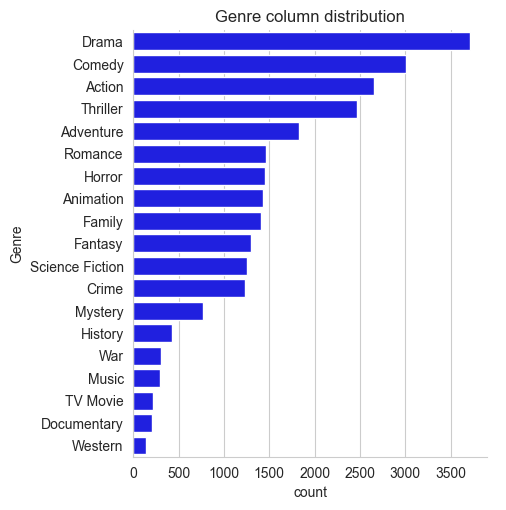

In [175]:
sns.catplot(y ='Genre', data=df , kind='count',
            order=df["Genre"].value_counts().index,
            color="blue")

plt.title('Genre column distribution')
plt.show()

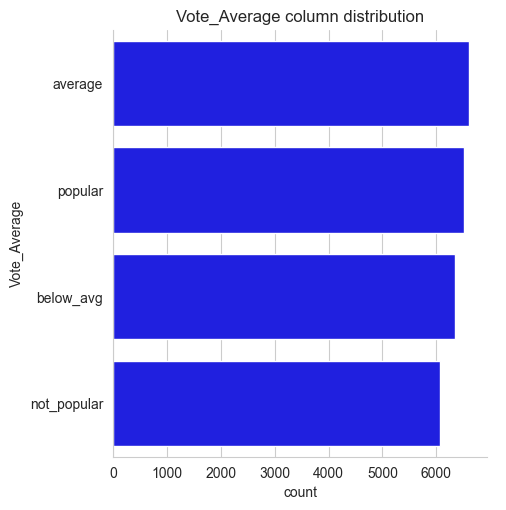

In [177]:
sns.catplot(y ='Vote_Average', data=df , kind='count',
            order=df["Vote_Average"].value_counts().index,
            color="blue")

plt.title('Vote_Average column distribution')
plt.show()

In [181]:
df[df["Popularity"] == df["Popularity"].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


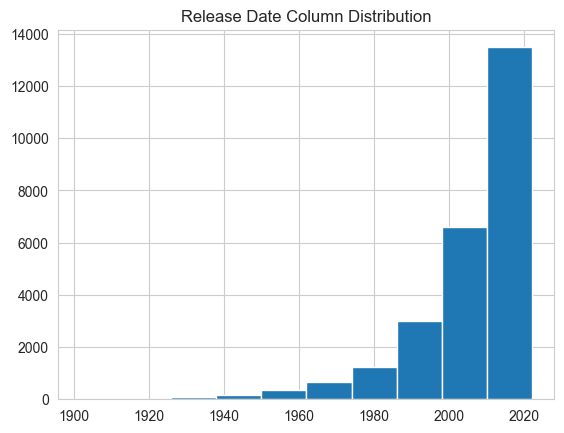

In [184]:
df["Release_Date"].hist()
plt.title("Release Date Column Distribution")
plt.show()